In [10]:
import matplotlib.pyplot as plt
import numpy as np


class util(object):

    @staticmethod
    def load_dataset(csv_path, label_col='y', add_intercept=False):
        """Load dataset from a CSV file.

        Args:
            csv_path: Path to CSV file containing dataset.
            label_col: Name of column to use as labels (should be 'y' or 't').
            add_intercept: Add an intercept entry to x-values.

        Returns:
            xs: Numpy array of x-values (inputs).
            ys: Numpy array of y-values (labels).
        """
        # Validate label_col argument
        allowed_label_cols = ('y', 't')
        if label_col not in allowed_label_cols:
            raise ValueError(
                f'Invalid label_col: {label_col} (expected one of {allowed_label_cols})'
            )

        # Load headers
        with open(csv_path, 'r') as csv_fh:
            headers = csv_fh.readline().strip().split(',')

        # Load features and labels
        x_cols = [i for i in range(len(headers)) if headers[i].startswith('x')]
        l_cols = [i for i in range(len(headers)) if headers[i] == label_col]
        inputs = np.loadtxt(csv_path, delimiter=',', skiprows=1, usecols=x_cols)
        labels = np.loadtxt(csv_path, delimiter=',', skiprows=1, usecols=l_cols)

        if inputs.ndim == 1:
            inputs = np.expand_dims(inputs, -1)

        if add_intercept:
            inputs = util.add_intercept(inputs)

        return inputs, labels

    @staticmethod
    def plot(X, labels, centroids, save_path):
        plt.figure(figsize=(8, 6))

        # Plot data points
        for k in range(len(centroids)):
            points = X[labels == k]
            plt.scatter(
                points[:, 0],
                points[:, 1],
                label=f"Cluster {k}"
            )

        # Plot centroids
        plt.scatter(
            centroids[:, 0],
            centroids[:, 1],
            marker="X",
            s=200,
            label="Centroids"
        )

        if save_path is not None:
            plt.savefig(save_path)
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.title("K-Means Clustering")
        plt.legend()
        plt.show()


In [15]:
class KMeansClustering(object):
    
    def __init__(self, n_clusters, max_iters=100, random_state=None):
        
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None

    def fit(self, X):

        np.random.seed(self.random_state)

        # Initialize centroids randomly
        idx = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[idx]
        print(len(self.centroids))

        while True:
            #Assign points to nearest centroid
            distances = self._calculate_distances(X)
            labels = np.argmin(distances, axis=0)

            #Update centroids
            new_centroids = np.array([
                X[labels == k].mean(axis=0)
                for k in range(self.n_clusters)
            ])

            # Check for convergence
            if np.all(self.centroids == new_centroids):
                break

            self.centroids = new_centroids

        return labels
            
    def predict(self, X):
        distances = self._calculate_distances(X)
        return np.argmin(distances, axis=0)

    def _calculate_distances(self, X):
        """
        Calculate distances bretween each point in X and all centroids.
        """
        n_samples = X.shape[0]
        distances = np.zeros((self.n_clusters, n_samples))

        for i in range(n_samples):
            diff = self.centroids - X[i]
            distances[:, i] = np.linalg.norm(diff, axis=1)

        return distances

In [20]:
def cluster_accuracy(y_true, y_pred, n_clusters):
    
    best_accuracy = 0

    # Try every possible mapping between clusters and classes
    import itertools

    for mapping in itertools.permutations(range(n_clusters)):

        mapped_pred = np.array([
            mapping[label]
            for label in y_pred
        ])

        accuracy = np.mean(mapped_pred == y_true)

        if accuracy > best_accuracy:
            best_accuracy = accuracy

    return best_accuracy

3
Train accuracy: 1.0
Test accuracy: 1.0


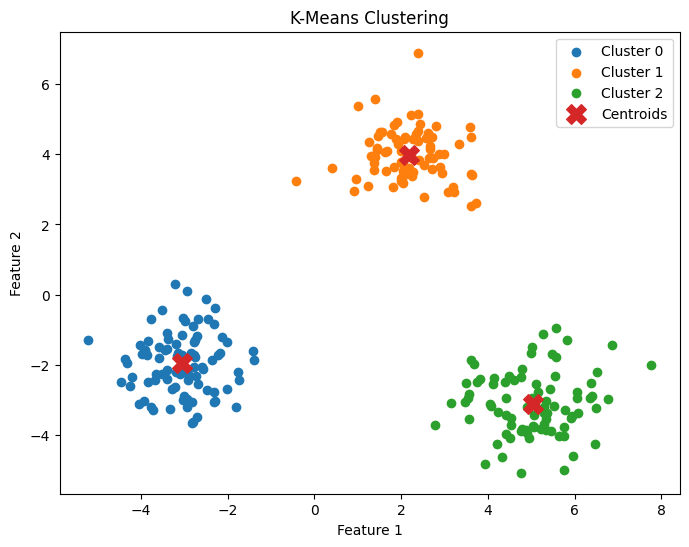

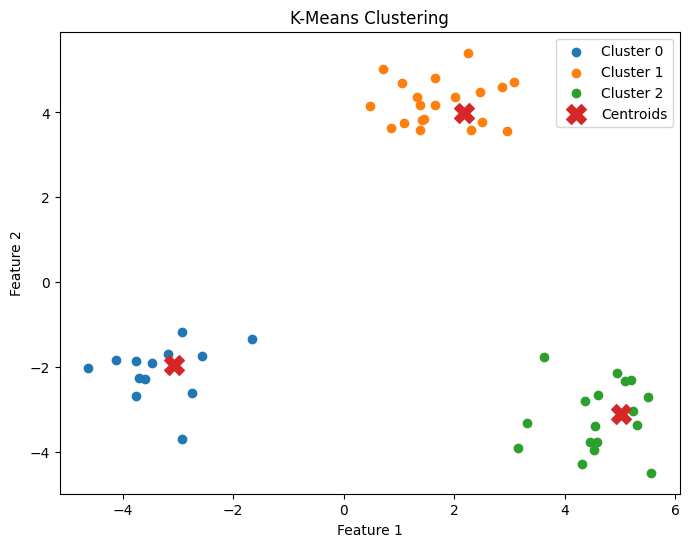

In [21]:

    
def run(train_path, eval_path, pred_path):

    X_train, y_train = util.load_dataset(train_path)

    model = KMeansClustering(
        n_clusters=3,
        max_iters=100,
        random_state=42
    )

    train_labels = model.fit(X_train)

    X_test, y_test = util.load_dataset(eval_path)

    test_labels = model.predict(X_test)

    # Evaluate
    train_accuracy = cluster_accuracy(
        y_train,
        train_labels,
        model.n_clusters
    )

    test_accuracy = cluster_accuracy(
        y_test,
        test_labels,
        model.n_clusters
    )

    print("Train accuracy:", train_accuracy)
    print("Test accuracy:", test_accuracy)

    util.plot(
        X_train,
        train_labels,
        model.centroids,
        save_path="Output/KmeansClusteringTrainData.png"
    )

    util.plot(
        X_test,
        test_labels,
        model.centroids,
        save_path="Output/KmeansClusteringEvalData.png"
    )

    
if __name__ == "__main__":
    run(train_path="Data/train.csv",
        eval_path="Data/test.csv",
        pred_path="Output/KMeansClustering.txt")
    